# Install & Import Library

In [27]:
%pip install torch
%pip install transformers
%pip install conllu
%pip install pandas numpy scikit-learn matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [59]:
import conllu
import os
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt



# -----------------------------------------------------------------------

# Explore Dataset IndoLEM

## A. Explore Task Dataset - UD_Indonesian_GSD (RAW)

### 1. Set Path & Counting Dataset Sentence

In [29]:
BASE_PATH = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\raw\indolem-main\dependency_parsing"

PATH_GSD_TRAIN = os.path.join(BASE_PATH, "UD_Indonesian_GSD", "id_gsd-ud-train.conllu")
PATH_GSD_DEV   = os.path.join(BASE_PATH, "UD_Indonesian_GSD", "id_gsd-ud-dev.conllu")
PATH_GSD_TEST  = os.path.join(BASE_PATH, "UD_Indonesian_GSD", "id_gsd-ud-test.conllu")

### 2. Exploration Raw Data

In [30]:
import pandas as pd
from IPython.display import display

# ============================================
# BACA DATA GSD
# ============================================
with open(PATH_GSD_TRAIN, "r", encoding="utf-8") as f:
    data_gsd_train = conllu.parse(f.read())
with open(PATH_GSD_DEV, "r", encoding="utf-8") as f:
    data_gsd_dev = conllu.parse(f.read())
with open(PATH_GSD_TEST, "r", encoding="utf-8") as f:
    data_gsd_test = conllu.parse(f.read())

data_gsd_all = data_gsd_train + data_gsd_dev + data_gsd_test

# ============================================
# AMBIL SAMPLE RAW DATA DARI GSD
# ============================================
raw_data = []

for kalimat in data_gsd_all[:50]:  # ambil 50 kalimat pertama
    teks = kalimat.metadata.get('text', '')
    sent_id = kalimat.metadata.get('sent_id', '')
    
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
            
        raw_data.append({
            'sent_id'  : sent_id,
            'teks'     : teks,
            'token_id' : token['id'],
            'token'    : token['form'],
            'lemma'    : token['lemma'],
            'upos'     : token['upos'],
            'xpos'     : token['xpos'],
            'feats'    : str(token['feats']) if token['feats'] else '-',
            'head'     : token['head'],
            'deprel'   : token['deprel'],
            'misc'     : str(token['misc']) if token['misc'] else '-',
        })

df_raw = pd.DataFrame(raw_data)

# ============================================
# TAMPILKAN STATISTIK LABEL
# ============================================
print("=" * 60)
print("INFORMASI RAW DATA UD-INDO-GSD")
print("=" * 60)

print(f"\n{'Jumlah kalimat (all)':<30}: {len(data_gsd_all)}")
print(f"{'Jumlah kalimat (train)':<30}: {len(data_gsd_train)}")
print(f"{'Jumlah kalimat (dev)':<30}: {len(data_gsd_dev)}")
print(f"{'Jumlah kalimat (test)':<30}: {len(data_gsd_test)}")

# Hitung total token
total_token = sum(
    1 for kalimat in data_gsd_all
    for token in kalimat
    if isinstance(token['id'], int)
)
total_token_no_punct = sum(
    1 for kalimat in data_gsd_all
    for token in kalimat
    if isinstance(token['id'], int) and token['upos'] != 'PUNCT'
)
print(f"\n{'Total token':<30}: {total_token}")
print(f"{'Total token (no punct)':<30}: {total_token_no_punct}")

# ============================================
# TABEL 1: FIELD YANG TERSEDIA
# ============================================
print("\n\n=== TABEL 1: FIELD YANG TERSEDIA ===")
fields_info = {
    'sent_id' : 'ID kalimat',
    'token'   : 'Bentuk token asli',
    'lemma'   : 'Bentuk dasar token',
    'upos'    : 'Universal POS tag',
    'xpos'    : 'Language-specific POS tag',
    'feats'   : 'Morphological features',
    'head'    : 'ID token kepala (dependency)',
    'deprel'  : 'Dependency relation label',
    'misc'    : 'Informasi tambahan (MorphInd)',
}

df_fields = pd.DataFrame([
    {'FIELD': k, 'KETERANGAN': v}
    for k, v in fields_info.items()
])
display(df_fields)

# ============================================
# TABEL 2: DISTRIBUSI UPOS
# ============================================
print("\n\n=== TABEL 2: DISTRIBUSI UPOS ===")
upos_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if isinstance(token['id'], int) and token['upos'] != 'PUNCT':
            upos_data.append(token['upos'])

from collections import Counter
upos_counter = Counter(upos_data)
total = sum(upos_counter.values())

df_upos = pd.DataFrame([
    {
        'UPOS'       : upos,
        'JUMLAH'     : count,
        'PERSENTASE' : f"{count/total*100:.1f}%",
        'KETERANGAN' : {
            'NOUN' : 'Kata benda',
            'VERB' : 'Kata kerja',
            'ADJ'  : 'Kata sifat',
            'ADV'  : 'Kata keterangan',
            'PROPN': 'Kata benda proper',
            'DET'  : 'Determiner',
            'ADP'  : 'Adposisi',
            'PRON' : 'Kata ganti',
            'CCONJ': 'Konjungsi koordinatif',
            'SCONJ': 'Konjungsi subordinatif',
            'NUM'  : 'Numeralia',
            'AUX'  : 'Kata bantu',
            'PART' : 'Partikel',
            'INTJ' : 'Interjeksi',
            'SYM'  : 'Simbol',
            'X'    : 'Lainnya',
        }.get(upos, '-')
    }
    for upos, count in upos_counter.most_common()
])
display(df_upos)

# ============================================
# TABEL 3: DISTRIBUSI DEPREL
# ============================================


# KETERANGAN DEPREL
DEPREL_KETERANGAN = {
    # Core arguments
    'root'       : 'Kata utama kalimat',
    'nsubj'      : 'Subjek nominal',
    'nsubj:pass' : 'Subjek nominal kalimat pasif',
    'obj'        : 'Objek langsung',
    'iobj'       : 'Objek tidak langsung',
    'csubj'      : 'Subjek klausal',
    'ccomp'      : 'Komplemen klausal',
    'xcomp'      : 'Komplemen klausal terbuka',

    # Nominal dependents
    'nmod'       : 'Modifier nominal',
    'nmod:poss'  : 'Modifier posesif',
    'appos'      : 'Aposisi',
    'nummod'     : 'Modifier numerik',
    'amod'       : 'Modifier adjektival',
    'det'        : 'Determiner',
    'clf'        : 'Classifier',
    'case'       : 'Preposisi/postposisi',

    # Verb dependents
    'obl'        : 'Keterangan oblique',
    'obl:agent'  : 'Keterangan agen (pasif)',
    'advmod'     : 'Modifier adverbial',
    'aux'        : 'Kata bantu',
    'aux:pass'   : 'Kata bantu pasif',
    'cop'        : 'Kopula',
    'compound'   : 'Kata majemuk',
    'flat'       : 'Ekspresi flat (nama)',
    'flat:name'  : 'Nama diri',
    'fixed'      : 'Ekspresi tetap',

    # Coordination
    'conj'       : 'Konjungsi koordinatif',
    'cc'         : 'Konjungsi koordinatif (kata)',
    'cc:preconj' : 'Konjungsi pre-koordinatif',

    # Clausal dependents
    'acl'        : 'Klausa adjektival',
    'acl:relcl'  : 'Klausa relatif',
    'advcl'      : 'Klausa adverbial',
    'mark'       : 'Penanda klausa (bahwa/yang)',
    'parataxis'  : 'Hubungan parataktis',
    'list'       : 'Hubungan list',
    'orphan'     : 'Orphan (ellipsis)',
    'reparandum' : 'Koreksi ujaran',
    'discourse'  : 'Penanda wacana',

    # Special
    'punct'      : 'Tanda baca',
    'dep'        : 'Dependensi tidak terspesifikasi',
    'goeswith'   : 'Bagian dari kata yang sama',
    'vocative'   : 'Vokativa',
    'expl'       : 'Ekspletif',
    'dislocated' : 'Dislokasi',
}


print("=== TABEL DISTRIBUSI DEPREL ===")

deprel_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if isinstance(token['id'], int) and token['upos'] != 'PUNCT':
            deprel_data.append(token['deprel'])

deprel_counter = Counter(deprel_data)
total_deprel   = sum(deprel_counter.values())

df_deprel = pd.DataFrame([
    {
        'DEPREL'     : deprel,
        'JUMLAH'     : count,
        'PERSENTASE' : f"{count/total_deprel*100:.1f}%",
        'KETERANGAN' : DEPREL_KETERANGAN.get(deprel, '-')
    }
    for deprel, count in deprel_counter.most_common()
])
display(df_deprel)


# ============================================
# TABEL 4: DISTRIBUSI FEATS
# ============================================

# KETERANGAN MORPHOLOGICAL FEATURES

FEATS_KETERANGAN = {
    # Voice
    'Voice=Act'         : 'Verba aktif (me-)',
    'Voice=Pass'        : 'Verba pasif (di-)',

    # Number
    'Number=Sing'       : 'Bentuk tunggal',
    'Number=Plur'       : 'Bentuk jamak',

    # PronType
    'PronType=Rel'      : 'Pronomina relatif (yang)',
    'PronType=Dem'      : 'Pronomina demonstratif (ini/itu)',
    'PronType=Ind'      : 'Pronomina indefinit (sebuah)',
    'PronType=Prs'      : 'Pronomina persona (saya/dia)',
    'PronType=Int'      : 'Pronomina interogatif (apa/siapa)',
    'PronType=Tot'      : 'Pronomina total (semua)',
    'PronType=Neg'      : 'Pronomina negatif (tidak ada)',

    # Degree
    'Degree=Pos'        : 'Adjektiva positif',
    'Degree=Cmp'        : 'Adjektiva komparatif (lebih)',
    'Degree=Sup'        : 'Adjektiva superlatif (paling)',

    # NumType
    'NumType=Card'      : 'Numeralia kardinal (satu, dua)',
    'NumType=Ord'       : 'Numeralia ordinal (pertama, kedua)',
    'NumType=Frac'      : 'Numeralia pecahan (setengah)',
    'NumType=Mult'      : 'Numeralia multiplikatif (dua kali)',
    'NumType=Dist'      : 'Numeralia distributif',
    'NumType=Sets'      : 'Numeralia set',

    # Person
    'Person=1'          : 'Persona pertama (saya/kami)',
    'Person=2'          : 'Persona kedua (kamu/Anda)',
    'Person=3'          : 'Persona ketiga (dia/mereka)',

    # Polarity
    'Polarity=Neg'      : 'Negasi (tidak/bukan/belum)',
    'Polarity=Pos'      : 'Positif (afirmatif)',

    # Possessor
    'Number[psor]=Sing' : 'Pemilik tunggal (-nya/-ku/-mu)',
    'Number[psor]=Plur' : 'Pemilik jamak',
    'Person[psor]=1'    : 'Pemilik persona pertama (-ku)',
    'Person[psor]=2'    : 'Pemilik persona kedua (-mu)',
    'Person[psor]=3'    : 'Pemilik persona ketiga (-nya)',

    # Polite
    'Polite=Form'       : 'Bentuk formal/hormat (Anda)',
    'Polite=Infm'       : 'Bentuk informal (kamu)',

    # Clusivity
    'Clusivity=Ex'      : 'Eksklusif (kami — tidak termasuk lawan bicara)',
    'Clusivity=In'      : 'Inklusif (kita — termasuk lawan bicara)',

    # Gender
    'Gender=Masc'       : 'Maskulin',
    'Gender=Fem'        : 'Feminin',

    # Mood
    'Mood=Imp'          : 'Modus imperatif (perintah)',
    'Mood=Ind'          : 'Modus indikatif (pernyataan)',
    'Mood=Sub'          : 'Modus subjunktif',

    # Aspect
    'Aspect=Perf'       : 'Aspek perfektif (sudah)',
    'Aspect=Imp'        : 'Aspek imperfektif (sedang)',
    'Aspect=Iter'       : 'Aspek iteratif (berulang)',
}

print("\n\n=== TABEL DISTRIBUSI MORPHOLOGICAL FEATURES ===")

feats_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
        if token['upos'] == 'PUNCT':
            continue
        if token['feats']:
            for key, val in token['feats'].items():
                feats_data.append(f"{key}={val}")

feats_counter = Counter(feats_data)
total_feats   = sum(feats_counter.values())

df_feats = pd.DataFrame([
    {
        'FEATURE'    : feat,
        'JUMLAH'     : count,
        'PERSENTASE' : f"{count/total_feats*100:.1f}%",
        'KETERANGAN' : FEATS_KETERANGAN.get(feat, '-')
    }
    for feat, count in feats_counter.most_common()
])
display(df_feats)


# ============================================
# TABEL 5: SAMPLE RAW DATA LENGKAP
# ============================================
print("\n\n=== TABEL 5: SAMPLE RAW DATA (20 baris pertama) ===")
display(df_raw[['sent_id', 'token', 'lemma', 'upos', 'xpos',
                'feats', 'head', 'deprel', 'misc']].head(20))

INFORMASI RAW DATA UD-INDO-GSD

Jumlah kalimat (all)          : 5593
Jumlah kalimat (train)        : 4477
Jumlah kalimat (dev)          : 559
Jumlah kalimat (test)         : 557

Total token                   : 121923
Total token (no punct)        : 103695


=== TABEL 1: FIELD YANG TERSEDIA ===


,FIELD,KETERANGAN
0,sent_id,ID kalimat
1,token,Bentuk token asli
2,lemma,Bentuk dasar token
3,upos,Universal POS tag
4,xpos,Language-specific POS tag
5,feats,Morphological features
6,head,ID token kepala (dependency)
7,deprel,Dependency relation label
8,misc,Informasi tambahan (MorphInd)




=== TABEL 2: DISTRIBUSI UPOS ===


,UPOS,JUMLAH,PERSENTASE,KETERANGAN
0,NOUN,27000,26.0%,Kata benda
1,PROPN,22790,22.0%,Kata benda proper
2,VERB,12202,11.8%,Kata kerja
3,ADP,12019,11.6%,Adposisi
4,PRON,4764,4.6%,Kata ganti
5,ADV,4760,4.6%,Kata keterangan
6,ADJ,4528,4.4%,Kata sifat
7,NUM,4383,4.2%,Numeralia
8,DET,4012,3.9%,Determiner
9,CCONJ,3659,3.5%,Konjungsi koordinatif


=== TABEL DISTRIBUSI DEPREL ===


,DEPREL,JUMLAH,PERSENTASE,KETERANGAN
0,case,11897,11.5%,Preposisi/postposisi
1,flat,11402,11.0%,Ekspresi flat (nama)
2,compound,7428,7.2%,Kata majemuk
3,nsubj,7125,6.9%,Subjek nominal
4,obl,6346,6.1%,Keterangan oblique
5,obj,5794,5.6%,Objek langsung
6,root,5592,5.4%,Kata utama kalimat
7,advmod,5288,5.1%,Modifier adverbial
8,conj,4806,4.6%,Konjungsi koordinatif
9,amod,4566,4.4%,Modifier adjektival




=== TABEL DISTRIBUSI MORPHOLOGICAL FEATURES ===


,FEATURE,JUMLAH,PERSENTASE,KETERANGAN
0,Number=Sing,49801,56.5%,Bentuk tunggal
1,Voice=Act,9352,10.6%,Verba aktif (me-)
2,Degree=Pos,6001,6.8%,Adjektiva positif
3,NumType=Card,4714,5.3%,"Numeralia kardinal (satu, dua)"
4,Voice=Pass,3527,4.0%,Verba pasif (di-)
5,PronType=Rel,3110,3.5%,Pronomina relatif (yang)
6,PronType=Dem,2048,2.3%,Pronomina demonstratif (ini/itu)
7,Number[psor]=Sing,1877,2.1%,Pemilik tunggal (-nya/-ku/-mu)
8,Person[psor]=3,1785,2.0%,Pemilik persona ketiga (-nya)
9,PronType=Ind,1138,1.3%,Pronomina indefinit (sebuah)




=== TABEL 5: SAMPLE RAW DATA (20 baris pertama) ===


,sent_id,token,lemma,upos,xpos,feats,head,deprel,misc
0,train-s1,Sembungan,sembungan,PROPN,X--,-,4,nsubj,{'MorphInd': '^sembungan<x>_X--$'}
1,train-s1,adalah,adalah,AUX,O--,-,4,cop,{'MorphInd': '^adalah<o>_O--$'}
2,train-s1,sebuah,sebuah,DET,B--,{'PronType': 'Ind'},4,det,{'MorphInd': '^sebuah<b>_B--$'}
3,train-s1,desa,desa,NOUN,NSD,{'Number': 'Sing'},0,root,{'MorphInd': '^desa<n>_NSD$'}
4,train-s1,yang,yang,PRON,S--,{'PronType': 'Rel'},6,nsubj:pass,{'MorphInd': '^yang<s>_S--$'}
5,train-s1,terletak,terletak,VERB,VSP,"{'Number': 'Sing', 'Voice': 'Pass'}",4,acl,{'MorphInd': '^ter+letak<n>_VSP$'}
6,train-s1,di,di,ADP,R--,-,8,case,{'MorphInd': '^di<r>_R--$'}
7,train-s1,kecamatan,kecamatan,NOUN,NSD,{'Number': 'Sing'},6,obl,{'MorphInd': '^ke+camat<n>+an_NSD$'}
8,train-s1,Kejajar,kejajar,PROPN,X--,-,8,flat,"{'SpaceAfter': 'No', 'MorphInd': '^kejajar<x>_..."
9,train-s1,",",",",PUNCT,Z--,-,8,punct,"{'MorphInd': '^,<z>_Z--$'}"


# -----------------------------------------------------------------------

# Preprocessing Data (Adding Label)

## A. Morfologi Afiksasi (Prefiks, Sufiks, Konfiks)

### Constanta Initialization

In [31]:
# ============================================
# KONSTANTA PREFIKS
# ============================================
NORMALISASI_PREFIKS = {
    'mem' : 'me', 'men' : 'me', 'meng': 'me',
    'meny': 'me', 'mel' : 'me', 'mer' : 'me',
    'me'  : 'me',
    'pem' : 'pe', 'pen' : 'pe', 'peng': 'pe',
    'peny': 'pe', 'pel' : 'pe', 'per' : 'pe',
    'pe'  : 'pe',
    'di'  : 'di',
    'ber' : 'ber', 'be'  : 'ber', 'bel' : 'ber',
    'ter' : 'ter',
    'ke'  : 'ke',
    'se'  : 'se',
}
PREFIKS_DIKENAL = set(NORMALISASI_PREFIKS.keys())

# ============================================
# KONSTANTA SUFIKS
# ============================================
SUFIKS_DIKENAL = {
    'kan', 'i',
    'an', 'wan', 'wati', 'man',
    'wi', 'iah', 'wiah',
    'nya',
    'isme', 'asi', 'isasi', 'logi', 'tas',
    'if', 'al', 'is',
}

SUFIKS_KELAS_BENTUK = {
    'kan'  : 'VERB', 'i'    : 'VERB',
    'an'   : 'NOUN', 'wan'  : 'NOUN', 'wati' : 'NOUN',
    'man'  : 'NOUN', 'isme' : 'NOUN', 'asi'  : 'NOUN',
    'isasi': 'NOUN', 'logi' : 'NOUN', 'tas'  : 'NOUN',
    'wi'   : 'ADJ',  'iah'  : 'ADJ',  'wiah' : 'ADJ',
    'if'   : 'ADJ',  'al'   : 'ADJ',  'is'   : 'ADJ',
    'nya'  : 'ADV',
}

SUFIKS_RAWAN     = {'al', 'is', 'if', 'i', 'an', 'man'}

SUFIKS_UPOS_VALID = {
    'kan'  : {'VERB'},
    'i'    : {'VERB'},
    'an'   : {'NOUN', 'VERB', 'ADJ', 'ADV'},
    'wan'  : {'NOUN'},
    'wati' : {'NOUN'},
    'man'  : {'NOUN'},
    'isme' : {'NOUN'},
    'asi'  : {'NOUN'},
    'isasi': {'NOUN'},
    'logi' : {'NOUN'},
    'tas'  : {'NOUN'},
    'wi'   : {'ADJ'},
    'iah'  : {'ADJ', 'NOUN'},
    'wiah' : {'ADJ'},
    'if'   : {'ADJ'},
    'al'   : {'ADJ'},
    'is'   : {'ADJ'},
    'nya'  : {'ADV', 'NOUN', 'VERB', 'ADJ'},
}

KELAS_KATA_VALID = {'n', 'v', 'a', 'b', 's', 'r', 'o'}

# ============================================
# FUNGSI HELPER
# ============================================
def get_kelas_kata(morfologi_str):
    match = re.search(r'<([^>]+)>', morfologi_str)
    return match.group(1).lower() if match else None

def get_morfologi_segmen(morphind_str):
    """Ambil segmen morfologi dari MorphInd"""
    s = morphind_str.strip('^$')
    first_underscore = s.find('_')
    morfologi = s[:first_underscore] if first_underscore != -1 else s
    kelas_kata = get_kelas_kata(morfologi)
    morfologi_bersih = re.sub(r'<[^>]+>', '', morfologi)
    segmen = [x.lower() for x in morfologi_bersih.split('+') if x]
    return segmen, kelas_kata

def is_sufiks_valid(sufiks, kelas_kata, upos):
    if sufiks in SUFIKS_RAWAN:
        if kelas_kata not in KELAS_KATA_VALID:
            return False
    if sufiks in SUFIKS_UPOS_VALID:
        if upos not in SUFIKS_UPOS_VALID[sufiks]:
            return False
    return True


### Prefiks Detection

In [32]:
def deteksi_prefiks(morphind_str, upos=None):
    """
    Deteksi PREFIKS dari MorphInd
    Hanya return hasil jika tipe = prefiks murni
    (tidak ada sufiks sekaligus)
    """
    segmen, kelas_kata = get_morfologi_segmen(morphind_str)

    if len(segmen) == 2:
        # prefiks + root (tanpa sufiks)
        if (segmen[0] in PREFIKS_DIKENAL and
            segmen[1] not in SUFIKS_DIKENAL):
            return {
                'prefiks'   : NORMALISASI_PREFIKS[segmen[0]],
                'root'      : segmen[1],
                'kelas_kata': kelas_kata
            }

    elif len(segmen) == 3:
        # prefiks + per + root
        if (segmen[0] in PREFIKS_DIKENAL and
            segmen[1] == 'per' and
            segmen[2] not in SUFIKS_DIKENAL):
            return {
                'prefiks'   : NORMALISASI_PREFIKS[segmen[0]],
                'root'      : f"per+{segmen[2]}",
                'kelas_kata': kelas_kata
            }
        # prefiks + root + root (bukan sufiks)
        elif (segmen[0] in PREFIKS_DIKENAL and
              segmen[2] not in SUFIKS_DIKENAL):
            return {
                'prefiks'   : NORMALISASI_PREFIKS[segmen[0]],
                'root'      : '+'.join(segmen[1:]),
                'kelas_kata': kelas_kata
            }

    return None

# Kumpulkan data prefiks
prefiks_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
        if token['upos'] == 'PUNCT':
            continue
        if not token['misc'] or 'MorphInd' not in str(token['misc']):
            continue

        morphind_str = token['misc']['MorphInd']
        hasil = deteksi_prefiks(morphind_str, upos=token['upos'])

        if hasil:
            prefiks_data.append({
                'token'     : token['form'],
                'lemma'     : token['lemma'],
                'upos'      : token['upos'],
                'prefiks'   : hasil['prefiks'],
                'root'      : hasil['root'],
                'kelas_kata': hasil['kelas_kata'],
                'deprel'    : token['deprel'],
                'morphind'  : morphind_str
            })

df_prefiks = pd.DataFrame(prefiks_data)

# Output
print("=== EKSPLORASI PREFIKS ===")
print(f"Total token berprefiks : {len(df_prefiks)}")
print(f"\nDistribusi per prefiks :")
print(df_prefiks['prefiks'].value_counts().to_string())
print(f"\nContoh per prefiks (5 contoh):")
for prefiks in df_prefiks['prefiks'].unique():
    contoh = df_prefiks[df_prefiks['prefiks'] == prefiks]['token'].head(5).tolist()
    print(f"  {prefiks:<6}: {contoh}")

=== EKSPLORASI PREFIKS ===
Total token berprefiks : 7540

Distribusi per prefiks :
prefiks
me     2354
ber    1776
di     1285
ter     951
pe      708
se      250
ke      216

Contoh per prefiks (5 contoh):
  ter   : ['terletak', 'terkenal', 'terletak', 'terkenal', 'terkena']
  me    : ['membakar', 'memperparah', 'membantunya', 'memberontak', 'melawan']
  pe    : ['penghuninya', 'perusak', 'pengujung', 'penyanyi', 'Pemimpin']
  di    : ['dipakai', 'dipakai', 'dimulailah', 'dirintis', 'didesain']
  ke    : ['keduanya', 'ketiganya', 'kedua', 'kedua', 'kedua']
  ber   : ['bermula', 'bervariasi', 'berbeda', 'berkomentar', 'berisi']
  se    : ['selain', 'selain', 'sejenis', 'Selain', 'sehari']


### Sufiks Detection

In [33]:
def deteksi_sufiks(morphind_str, upos=None):
    """
    Deteksi SUFIKS dari MorphInd
    Hanya return hasil jika tipe = sufiks murni
    (tidak ada prefiks sekaligus)
    """
    segmen, kelas_kata = get_morfologi_segmen(morphind_str)

    if len(segmen) == 2:
        # root + sufiks (tanpa prefiks)
        if (segmen[1] in SUFIKS_DIKENAL and
            segmen[0] not in PREFIKS_DIKENAL):
            if is_sufiks_valid(segmen[1], kelas_kata, upos):
                return {
                    'sufiks'      : segmen[1],
                    'root'        : segmen[0],
                    'kelas_kata'  : kelas_kata,
                    'kelas_bentuk': SUFIKS_KELAS_BENTUK.get(segmen[1], 'UNKNOWN')
                }

    return None

# Kumpulkan data sufiks
sufiks_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
        if token['upos'] == 'PUNCT':
            continue
        if not token['misc'] or 'MorphInd' not in str(token['misc']):
            continue

        morphind_str = token['misc']['MorphInd']
        hasil = deteksi_sufiks(morphind_str, upos=token['upos'])

        if hasil:
            sufiks_data.append({
                'token'       : token['form'],
                'lemma'       : token['lemma'],
                'upos'        : token['upos'],
                'sufiks'      : hasil['sufiks'],
                'root'        : hasil['root'],
                'kelas_kata'  : hasil['kelas_kata'],
                'kelas_bentuk': hasil['kelas_bentuk'],
                'deprel'      : token['deprel'],
                'morphind'    : morphind_str
            })

df_sufiks = pd.DataFrame(sufiks_data)

# Output
print("=== EKSPLORASI SUFIKS ===")
print(f"Total token bersufiks : {len(df_sufiks)}")
print(f"\nDistribusi per sufiks :")
print(df_sufiks['sufiks'].value_counts().to_string())
print(f"\nContoh per sufiks (5 contoh):")
for sufiks in df_sufiks['sufiks'].unique():
    contoh = df_sufiks[df_sufiks['sufiks'] == sufiks]['token'].head(5).tolist()
    kelas  = SUFIKS_KELAS_BENTUK.get(sufiks, 'UNKNOWN')
    print(f"  -{sufiks:<8} [{kelas:<5}]: {contoh}")

=== EKSPLORASI SUFIKS ===
Total token bersufiks : 1646

Distribusi per sufiks :
sufiks
an      1536
kan       57
wan       29
i         23
wati       1

Contoh per sufiks (5 contoh):
  -an       [NOUN ]: ['serangan', 'bangunan', 'bagian', 'harapan', 'rilisan']
  -kan      [VERB ]: ['lakukan', 'identifikasikan', 'sajikan', 'sahkan', 'tuliskan']
  -i        [VERB ]: ['pelopori', 'miliki', 'sayangi', 'akhiri', 'jumpai']
  -wan      [NOUN ]: ['karyawan', 'ilmuwan', 'ilmuwan', 'karyawannya', 'fisikawan']
  -wati     [NOUN ]: ['seniwati']


### Konfiks Detection

In [34]:
def deteksi_konfiks(morphind_str, upos=None):
    """
    Deteksi KONFIKS dari MorphInd
    Hanya return hasil jika ada PREFIKS DAN SUFIKS sekaligus
    """
    segmen, kelas_kata = get_morfologi_segmen(morphind_str)

    if len(segmen) == 3:
        # prefiks + root + sufiks
        if (segmen[0] in PREFIKS_DIKENAL and
            segmen[2] in SUFIKS_DIKENAL):
            if is_sufiks_valid(segmen[2], kelas_kata, upos):
                return {
                    'prefiks'     : NORMALISASI_PREFIKS[segmen[0]],
                    'sufiks'      : segmen[2],
                    'konfiks'     : f"{NORMALISASI_PREFIKS[segmen[0]]}-{segmen[2]}",
                    'root'        : segmen[1],
                    'kelas_kata'  : kelas_kata,
                    'kelas_bentuk': SUFIKS_KELAS_BENTUK.get(segmen[2], 'UNKNOWN')
                }

    elif len(segmen) == 4:
        # me + per + root + sufiks
        if (segmen[0] in PREFIKS_DIKENAL and
            segmen[1] == 'per' and
            segmen[3] in SUFIKS_DIKENAL):
            if is_sufiks_valid(segmen[3], kelas_kata, upos):
                return {
                    'prefiks'     : NORMALISASI_PREFIKS[segmen[0]],
                    'sufiks'      : segmen[3],
                    'konfiks'     : f"{NORMALISASI_PREFIKS[segmen[0]]}-{segmen[3]}",
                    'root'        : f"per+{segmen[2]}",
                    'kelas_kata'  : kelas_kata,
                    'kelas_bentuk': SUFIKS_KELAS_BENTUK.get(segmen[3], 'UNKNOWN')
                }
        # prefiks + root1 + root2 + sufiks
        elif (segmen[0] in PREFIKS_DIKENAL and
              segmen[3] in SUFIKS_DIKENAL):
            if is_sufiks_valid(segmen[3], kelas_kata, upos):
                return {
                    'prefiks'     : NORMALISASI_PREFIKS[segmen[0]],
                    'sufiks'      : segmen[3],
                    'konfiks'     : f"{NORMALISASI_PREFIKS[segmen[0]]}-{segmen[3]}",
                    'root'        : '+'.join(segmen[1:3]),
                    'kelas_kata'  : kelas_kata,
                    'kelas_bentuk': SUFIKS_KELAS_BENTUK.get(segmen[3], 'UNKNOWN')
                }

    return None

# Kumpulkan data konfiks
konfiks_data = []
for kalimat in data_gsd_all:
    for token in kalimat:
        if not isinstance(token['id'], int):
            continue
        if token['upos'] == 'PUNCT':
            continue
        if not token['misc'] or 'MorphInd' not in str(token['misc']):
            continue

        morphind_str = token['misc']['MorphInd']
        hasil = deteksi_konfiks(morphind_str, upos=token['upos'])

        if hasil:
            konfiks_data.append({
                'token'       : token['form'],
                'lemma'       : token['lemma'],
                'upos'        : token['upos'],
                'prefiks'     : hasil['prefiks'],
                'sufiks'      : hasil['sufiks'],
                'konfiks'     : hasil['konfiks'],
                'root'        : hasil['root'],
                'kelas_kata'  : hasil['kelas_kata'],
                'kelas_bentuk': hasil['kelas_bentuk'],
                'deprel'      : token['deprel'],
                'morphind'    : morphind_str
            })

df_konfiks = pd.DataFrame(konfiks_data)

# Output
print("=== EKSPLORASI KONFIKS ===")
print(f"Total token berkonfiks : {len(df_konfiks)}")
print(f"\nDistribusi per konfiks :")
print(df_konfiks['konfiks'].value_counts().to_string())
print(f"\nContoh per konfiks (5 contoh):")
for konfiks in df_konfiks['konfiks'].unique():
    contoh = df_konfiks[df_konfiks['konfiks'] == konfiks]['token'].head(5).tolist()
    print(f"  {konfiks:<12}: {contoh}")

=== EKSPLORASI KONFIKS ===
Total token berkonfiks : 6805

Distribusi per konfiks :
konfiks
pe-an      1609
me-kan     1575
ke-an      1191
di-kan     1150
me-i        784
di-i        293
ber-an      148
ber-kan      42
ter-kan       8
ter-i         4
ber-i         1

Contoh per konfiks (5 contoh):
  ke-an       : ['kecamatan', 'kegelapan', 'kerusakan', 'kegiatan', 'kecepatan']
  me-kan      : ['melarikan', 'menembakkan', 'melarikan', 'menyarangkan', 'melakukannya']
  pe-an       : ['Perkembangan', 'perbaikan', 'perbandingan', 'pendidikan', 'pemerintahan']
  di-i        : ['diikuti', 'disiasati', 'dialiri', 'dilengkapi', 'disutradarai']
  di-kan      : ['ditampilkan', 'didirikan', 'disebabkan', 'digunakan', 'diekspresikan']
  ber-an      : ['bertujuan', 'bermunculan', 'berpenghasilan', 'bersamaan', 'berkaitan']
  me-i        : ['memiliki', 'menjalani', 'mengikuti', 'memiliki', 'memiliki']
  ter-i       : ['tersaingi', 'terlindungi', 'terhalangi', 'terhalangi']
  ber-kan     : ['bersanda

### Visualization Morfologi Afiksasi Data Distribution

=== VISUALISASI DISTRIBUSI MORFOLOGI AFIKSASI ===



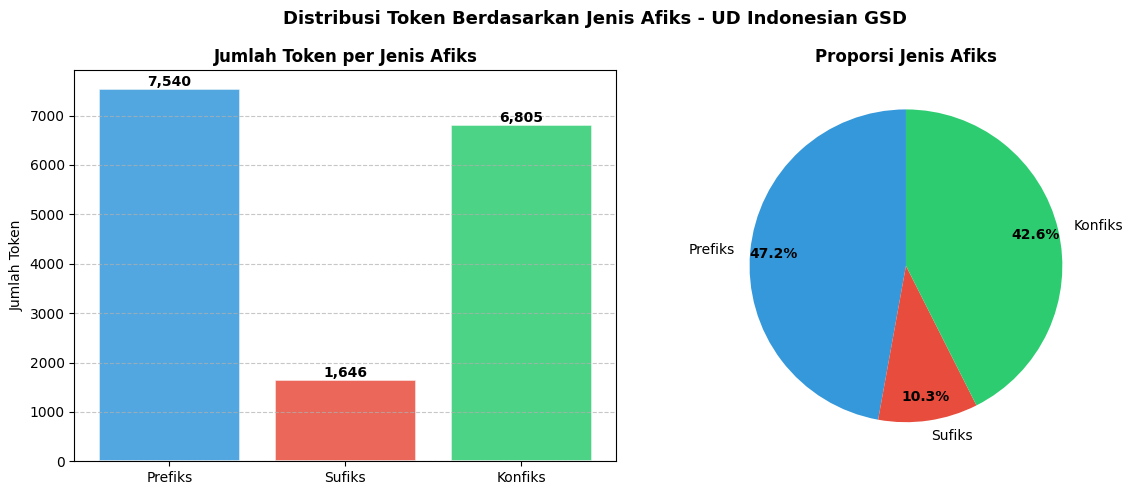

In [61]:
# ============================================
# VISUALISASI DISTRIBUSI MORFOLOGI AFIKSASI
# ============================================
print("=== VISUALISASI DISTRIBUSI MORFOLOGI AFIKSASI ===\n")

prefiks_count       = len(df_prefiks)
sufiks_count        = len(df_sufiks)
konfiks_count       = len(df_konfiks)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Token Berdasarkan Jenis Afiks - UD Indonesian GSD',
             fontsize=13, fontweight='bold')

colors = {
    'Prefiks': '#3498db',
    'Sufiks' : '#e74c3c',
    'Konfiks': '#2ecc71'
}

labels     = ['Prefiks', 'Sufiks', 'Konfiks']
counts     = [prefiks_count, sufiks_count, konfiks_count]
color_list = [colors[l] for l in labels]

# Plot 1: Bar chart
ax1  = axes[0]
bars = ax1.bar(labels, counts, color=color_list, alpha=0.85,
               edgecolor='white', linewidth=1.2)
ax1.set_title('Jumlah Token per Jenis Afiks', fontweight='bold')
ax1.set_ylabel('Jumlah Token')
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts, labels=labels, colors=color_list,
    autopct='%1.1f%%', startangle=90, pctdistance=0.85
)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
ax2.set_title('Proporsi Jenis Afiks', fontweight='bold')

plt.tight_layout()
plt.show()

### Adding Morfologi Afiksasi Label (Prefiks, Sufiks, Konfiks)

In [44]:
def proses_split(data_split):
    """
    Proses satu split → tambah label afiks ke raw data
    Format: kalimat, token, lemma, upos, xpos, feats, head, deprel, misc, tipe_afiks, label_afiks
    """
    processed = []

    for kalimat in data_split:
        teks    = kalimat.metadata.get('text', '')
        sent_id = kalimat.metadata.get('sent_id', '')

        for token in kalimat:
            if not isinstance(token['id'], int):
                continue
            if token['upos'] == 'PUNCT':
                continue

            # Deteksi afiks dulu
            tipe_afiks  = 'tidak_berafiks'
            label_afiks = '-'

            if token['misc'] and 'MorphInd' in str(token['misc']):
                morphind_str = token['misc']['MorphInd']

                # Prioritas 1: Konfiks
                hasil = deteksi_konfiks(morphind_str, upos=token['upos'])
                if hasil:
                    tipe_afiks  = 'konfiks'
                    label_afiks = hasil['konfiks']  # contoh: me-kan, ke-an

                # Prioritas 2: Prefiks
                elif deteksi_prefiks(morphind_str, upos=token['upos']):
                    hasil       = deteksi_prefiks(morphind_str, upos=token['upos'])
                    tipe_afiks  = 'prefiks'
                    label_afiks = hasil['prefiks']  # contoh: me, di, ber

                # Prioritas 3: Sufiks
                elif deteksi_sufiks(morphind_str, upos=token['upos']):
                    hasil       = deteksi_sufiks(morphind_str, upos=token['upos'])
                    tipe_afiks  = 'sufiks'
                    label_afiks = hasil['sufiks']   # contoh: kan, an, nya

            processed.append({
                'sent_id'    : sent_id,
                'kalimat'    : teks,
                'token'      : token['form'],
                'lemma'      : token['lemma'],
                'upos'       : token['upos'],
                'xpos'       : token['xpos'],
                'feats'      : str(token['feats']) if token['feats'] else '-',
                'head'       : token['head'],
                'deprel'     : token['deprel'],
                'misc'       : str(token['misc']) if token['misc'] else '-',
                'tipe_afiks' : tipe_afiks,
                'label_afiks': label_afiks,
            })

    return pd.DataFrame(processed)

### Save Processed Data

In [45]:
BASE_PROCESSED = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Morfologi_Afiksasi"
df_train = proses_split(data_gsd_train)
print(f"✓ Train : {len(df_train)} token")

df_dev = proses_split(data_gsd_dev)
print(f"✓ Dev   : {len(df_dev)} token")

df_test = proses_split(data_gsd_test)
print(f"✓ Test  : {len(df_test)} token")

# Buat folder langsung (tanpa subfolder train/dev/test)
os.makedirs(BASE_PROCESSED, exist_ok=True)

# Simpan langsung di MorfologiAfiksasi/
for split_name, df_split in [('train', df_train), ('dev', df_dev), ('test', df_test)]:
    path = os.path.join(BASE_PROCESSED, f"ud-indo-gsd_{split_name}_labeled.csv")
    df_split.to_csv(path, index=False, encoding='utf-8')
    print(f"✓ Disimpan: ud-indo-gsd_{split_name}_labeled.csv")

print("\nSemua data berhasil disimpan! ✅")

✓ Train : 82963 token
✓ Dev   : 10676 token
✓ Test  : 10056 token
✓ Disimpan: ud-indo-gsd_train_labeled.csv
✓ Disimpan: ud-indo-gsd_dev_labeled.csv
✓ Disimpan: ud-indo-gsd_test_labeled.csv

Semua data berhasil disimpan! ✅


In [46]:
# Ringkasan
print("=== RINGKASAN DISTRIBUSI AFIKS PER SPLIT ===\n")
print(f"{'TIPE AFIKS':<20} {'TRAIN':<10} {'DEV':<10} {'TEST':<10} {'TOTAL':<10}")
print("-" * 55)

for tipe in ['prefiks', 'sufiks', 'konfiks', 'tidak_berafiks']:
    c_train = len(df_train[df_train['tipe_afiks'] == tipe])
    c_dev   = len(df_dev[df_dev['tipe_afiks'] == tipe])
    c_test  = len(df_test[df_test['tipe_afiks'] == tipe])
    c_total = c_train + c_dev + c_test
    print(f"  {tipe:<20} {c_train:<10} {c_dev:<10} {c_test:<10} {c_total:<10}")

print("-" * 55)
total_all = len(df_train) + len(df_dev) + len(df_test)
print(f"  {'TOTAL':<20} {len(df_train):<10} {len(df_dev):<10} {len(df_test):<10} {total_all:<10}")

# Sample
print("\n\n=== SAMPLE DATA TRAIN ===")
cols = ['kalimat', 'token', 'lemma', 'upos', 'xpos',
        'feats', 'head', 'deprel', 'misc',
        'tipe_afiks', 'label_afiks']

for tipe in ['prefiks', 'sufiks', 'konfiks', 'tidak_berafiks']:
    print(f"\n--- {tipe.upper()} (3 contoh) ---")
    display(df_train[df_train['tipe_afiks'] == tipe][cols].head(3))

=== RINGKASAN DISTRIBUSI AFIKS PER SPLIT ===

TIPE AFIKS           TRAIN      DEV        TEST       TOTAL     
-------------------------------------------------------
  prefiks              5949       808        783        7540      
  sufiks               1335       151        160        1646      
  konfiks              5447       675        683        6805      
  tidak_berafiks       70232      9042       8430       87704     
-------------------------------------------------------
  TOTAL                82963      10676      10056      103695    


=== SAMPLE DATA TRAIN ===

--- PREFIKS (3 contoh) ---


,kalimat,token,lemma,upos,xpos,feats,head,deprel,misc,tipe_afiks,label_afiks
5,Sembungan adalah sebuah desa yang terletak di ...,terletak,terletak,VERB,VSP,"{'Number': 'Sing', 'Voice': 'Pass'}",4,acl,{'MorphInd': '^ter+letak<n>_VSP$'},prefiks,ter
23,Sebuah serangan pengayauan biasanya terjadi di...,membakar,menbakar,VERB,VSA,"{'Number': 'Sing', 'Voice': 'Act'}",7,acl,{'MorphInd': '^meN+bakar<v>_VSA$'},prefiks,me
29,Sebuah serangan pengayauan biasanya terjadi di...,penghuninya,penhuni,NOUN,NSD+PS3,"{'Number': 'Sing', 'Number[psor]': 'Sing', 'Pe...",14,obj,{'MorphInd': '^peN+huni<v>_NSD+dia<p>_PS3$'},prefiks,pe



--- SUFIKS (3 contoh) ---


,kalimat,token,lemma,upos,xpos,feats,head,deprel,misc,tipe_afiks,label_afiks
15,Sebuah serangan pengayauan biasanya terjadi di...,serangan,serangan,NOUN,NSD,{'Number': 'Sing'},5,nsubj,{'MorphInd': '^serang<v>+an_NSD$'},sufiks,an
77,"Dari jarak dekat, dua kapal perusak, Sterett d...",bangunan,bangunan,NOUN,NSD,{'Number': 'Sing'},14,obl,{'MorphInd': '^bangun<v>+an_NSD$'},sufiks,an
97,"Dari jarak dekat, dua kapal perusak, Sterett d...",bagian,bagian,NOUN,NSD,{'Number': 'Sing'},34,obl,{'MorphInd': '^bagi<v>+an_NSD$'},sufiks,an



--- KONFIKS (3 contoh) ---


,kalimat,token,lemma,upos,xpos,feats,head,deprel,misc,tipe_afiks,label_afiks
7,Sembungan adalah sebuah desa yang terletak di ...,kecamatan,kecamatan,NOUN,NSD,{'Number': 'Sing'},6,obl,{'MorphInd': '^ke+camat<n>+an_NSD$'},konfiks,ke-an
32,Sebuah serangan pengayauan biasanya terjadi di...,melarikan,menlarikan,VERB,VSA,"{'Number': 'Sing', 'Voice': 'Act'}",14,advcl,{'MorphInd': '^meN+lari<v>+kan_VSA$'},konfiks,me-kan
34,Perkembangan ini diikuti oleh helm Brodie yang...,Perkembangan,perkembangan,NOUN,NSD,{'Number': 'Sing'},3,nsubj:pass,{'MorphInd': '^per+kembang<n>+an_NSD$'},konfiks,pe-an



--- TIDAK_BERAFIKS (3 contoh) ---


,kalimat,token,lemma,upos,xpos,feats,head,deprel,misc,tipe_afiks,label_afiks
0,Sembungan adalah sebuah desa yang terletak di ...,Sembungan,sembungan,PROPN,X--,-,4,nsubj,{'MorphInd': '^sembungan<x>_X--$'},tidak_berafiks,-
1,Sembungan adalah sebuah desa yang terletak di ...,adalah,adalah,AUX,O--,-,4,cop,{'MorphInd': '^adalah<o>_O--$'},tidak_berafiks,-
2,Sembungan adalah sebuah desa yang terletak di ...,sebuah,sebuah,DET,B--,{'PronType': 'Ind'},4,det,{'MorphInd': '^sebuah<b>_B--$'},tidak_berafiks,-


### Visualization Morfologi Afiksasi On Processed Data

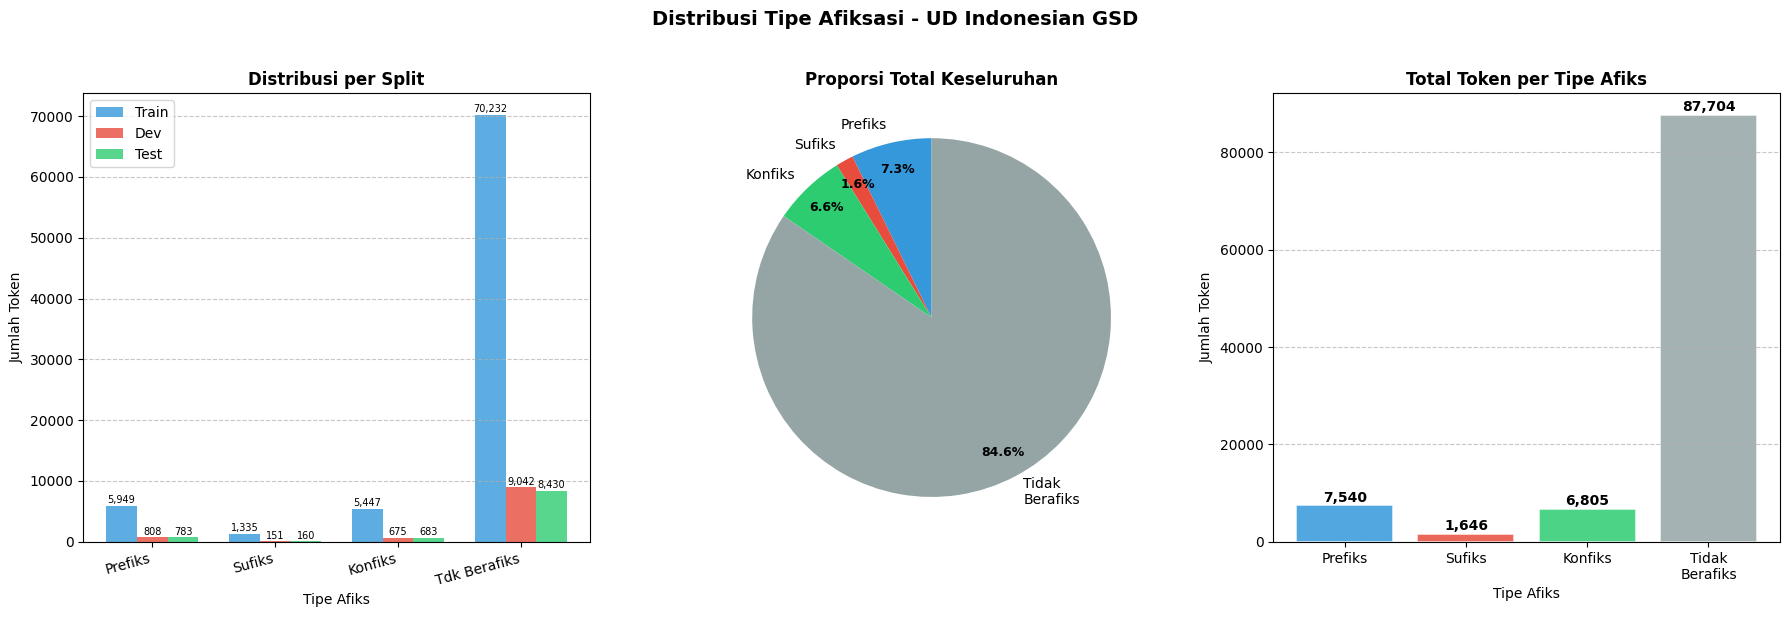

In [54]:
import matplotlib.pyplot as plt
import numpy as np


tipe_list = ['prefiks', 'sufiks', 'konfiks', 'tidak_berafiks']
counts = {}

for tipe in tipe_list:
    c_train = len(df_train[df_train['tipe_afiks'] == tipe])
    c_dev   = len(df_dev[df_dev['tipe_afiks'] == tipe])
    c_test  = len(df_test[df_test['tipe_afiks'] == tipe])
    
    counts[tipe] = {
        'train': c_train,
        'dev'  : c_dev,
        'test' : c_test,
        'total': c_train + c_dev + c_test
    }

colors = {
    'prefiks'       : '#3498db',
    'sufiks'        : '#e74c3c',
    'konfiks'       : '#2ecc71',
    'tidak_berafiks': '#95a5a6'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribusi Tipe Afiksasi - UD Indonesian GSD',
             fontsize=14, fontweight='bold', y=1.02)


# ============================================
# PLOT 1: Grouped Bar Chart per Split
# ============================================
ax1    = axes[0]
x      = np.arange(len(tipe_list))
width  = 0.25

bars_train = ax1.bar(x - width, [counts[t]['train'] for t in tipe_list],
                     width, label='Train', color='#3498db', alpha=0.8)
bars_dev   = ax1.bar(x,         [counts[t]['dev']   for t in tipe_list],
                     width, label='Dev',   color='#e74c3c', alpha=0.8)
bars_test  = ax1.bar(x + width, [counts[t]['test']  for t in tipe_list],
                     width, label='Test',  color='#2ecc71', alpha=0.8)

ax1.set_title('Distribusi per Split', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tipe Afiks')
ax1.set_ylabel('Jumlah Token')
ax1.set_xticks(x)
ax1.set_xticklabels(['Prefiks', 'Sufiks', 'Konfiks', 'Tdk Berafiks'],
                     rotation=15, ha='right')
ax1.legend()
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

for bars in [bars_train, bars_dev, bars_test]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, height + 50,
                     f'{int(height):,}', ha='center', va='bottom', fontsize=7)

# ============================================
# PLOT 2: Pie Chart Total
# ============================================
ax2        = axes[1]
totals     = [counts[t]['total'] for t in tipe_list]
labels     = ['Prefiks', 'Sufiks', 'Konfiks', 'Tidak\nBerafiks']
color_list = [colors[t] for t in tipe_list]

wedges, texts, autotexts = ax2.pie(
    totals,
    labels=labels,
    colors=color_list,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
)
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')

ax2.set_title('Proporsi Total Keseluruhan', fontsize=12, fontweight='bold')

# ============================================
# PLOT 3: Bar Chart Total per Tipe Afiks
# ============================================
ax3        = axes[2]
bar_colors = [colors[t] for t in tipe_list]
bars       = ax3.bar(
    ['Prefiks', 'Sufiks', 'Konfiks', 'Tidak\nBerafiks'],
    totals,
    color=bar_colors,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

ax3.set_title('Total Token per Tipe Afiks', fontsize=12, fontweight='bold')
ax3.set_xlabel('Tipe Afiks')
ax3.set_ylabel('Jumlah Token')
ax3.yaxis.grid(True, linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 100,
             f'{int(height):,}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## B. Negation

### Negation Detection

In [48]:
# =====================================================================
# IDENTIFIKASI NEG_CUE (MELALUI FILTERISASI FEATS POLARITY=NEG)
# =====================================================================

neg_cue_data          = []  # list kosong untuk menyimpan token NEG_CUE
kalimat_dengan_negasi = set()  # set untuk menyimpan sent_id kalimat yang mengandung negasi

for kalimat in data_gsd_all:    # iterasi setiap kalimat yang ada pada data_gsd_all(train+dev+test)
    teks    = kalimat.metadata.get('text', '') # mengambil teks kalimat lengkap dari metadata
    sent_id = kalimat.metadata.get('sent_id', '') # mengambil ID kalimat dari metadata

    for token in kalimat: # iterasi setiap token dalam kalimat
        if not isinstance(token['id'], int):    # filter token yang bukan kata (misal: multi-word token, empty node)
            continue
        if token['upos'] == 'PUNCT':    # filter token yang berupos tanda baca
            continue

        # Filter HANYA dari Polarity=Neg di FEATS
        if (token['feats'] and
            'Polarity' in token['feats'] and
            token['feats']['Polarity'] == 'Neg'): 

            kalimat_dengan_negasi.add(sent_id) # mencatat sent_id kalimat yang mengandung negasi
            neg_cue_data.append({   # menyimpan seluruh informasi token NEG_CUE ke dalam list
                'sent_id'  : sent_id,
                'kalimat'  : teks,
                'token_id' : token['id'],
                'token'    : token['form'],
                'lemma'    : token['lemma'],
                'upos'     : token['upos'],
                'xpos'     : token['xpos'],
                'feats'    : str(token['feats']),
                'head'     : token['head'],
                'deprel'   : token['deprel'],
                'misc'     : str(token['misc']) if token['misc'] else '-',
                'label'    : 'NEG_CUE'
            })

df_neg_cue = pd.DataFrame(neg_cue_data)

# ============================================
# PRINT TABLE DATA YANG MENGANDUNG NEG_CUE
# ============================================
print("=== STEP 1: IDENTIFIKASI NEG_CUE ===\n")
print(f"Total kalimat GSD              : {len(data_gsd_all)}")
print(f"Kalimat dengan Polarity=Neg    : {len(kalimat_dengan_negasi)}")
print(f"Kalimat tanpa Polarity=Neg     : {len(data_gsd_all) - len(kalimat_dengan_negasi)}")
print(f"\nTotal token NEG_CUE            : {len(df_neg_cue)}")
print(f"\nDistribusi token NEG_CUE :")
print(df_neg_cue['token'].value_counts().to_string())
print(f"\nDistribusi UPOS NEG_CUE :")
print(df_neg_cue['upos'].value_counts().to_string())

print(f"\n=== SAMPLE NEG_CUE (5 contoh) ===")
display(df_neg_cue[['sent_id',  'kalimat', 'token', 'lemma', 'upos',
                     'feats', 'head', 'deprel', 'label']].head(10))

=== STEP 1: IDENTIFIKASI NEG_CUE ===

Total kalimat GSD              : 5593
Kalimat dengan Polarity=Neg    : 495
Kalimat tanpa Polarity=Neg     : 5098

Total token NEG_CUE            : 543

Distribusi token NEG_CUE :
token
tidak             376
tak                46
bukan              40
Tidak              14
Bukankah           12
belum               9
bukanlah            6
non                 4
Tak                 4
jangan              3
tanpa               3
kan                 2
bukankah            2
anti                2
pun                 2
Tidakkah            2
tidakkah            2
Jangan              1
tiada               1
ketidakjelasan      1
Tanpa               1
nonbuku             1
Bukan               1
TIDAK               1
ketidakcukupan      1
bukannya            1
nonkriminal         1
ketidakpastian      1
tidaklah            1
ga                  1
t                   1

Distribusi UPOS NEG_CUE :
upos
PART     519
ADV       11
NOUN       8
PROPN      4
ADJ        

,sent_id,kalimat,token,lemma,upos,feats,head,deprel,label
0,train-s16,Tidak ada keterangan kejatuhan Yerusalem (berb...,Tidak,tidak,PART,{'Polarity': 'Neg'},2,advmod,NEG_CUE
1,train-s17,"Bang Yong Guk berkomentar, ""Tujuan saya dari a...",tidak,tidak,PART,{'Polarity': 'Neg'},12,advmod,NEG_CUE
2,train-s24,Bagaimana bisa kita tidak mengungkapkan kesedi...,tidak,tidak,PART,{'Polarity': 'Neg'},5,advmod,NEG_CUE
3,train-s53,"Khidir menjawab salamnya dan bertanya, ``Dari ...",tidak,tidak,PART,{'Polarity': 'Neg'},16,advmod,NEG_CUE
4,train-s71,"Membangun sebuah komunitas memang tidak mudah,...",tidak,tidak,PART,{'Polarity': 'Neg'},6,advmod,NEG_CUE
5,train-s83,Akan kan pertemanan sepihak ini dapat berubah ...,kan,kan,PART,{'Polarity': 'Neg'},7,advmod,NEG_CUE
6,train-s99,SPG Negeri 2 Bandung berlokasi di Jalan Citaru...,tidak,tidak,PART,{'Polarity': 'Neg'},25,advmod,NEG_CUE
7,train-s105,"Mengagumi Yukari, dan perlahan jatuh cinta pad...",tak,tak,PART,{'Polarity': 'Neg'},15,advmod,NEG_CUE
8,train-s115,Perhatikan bahwa nol di ruas kanan adalah vekt...,bukan,bukan,PART,{'Polarity': 'Neg'},12,advmod,NEG_CUE
9,train-s173,Walaupun warga non - Melayu tidak dimasukkan k...,non,non,PART,{'Polarity': 'Neg'},5,advmod,NEG_CUE


### Building Head Map

In [49]:
# =========================================================================
# BANGUN HEAD MAP UNTUK MENGIDENTIFIKASI SCOPE TOKEN YANG DIGUNAKAN
# =========================================================================

def bangun_head_map(kalimat):
    head_map = {}   # Dict kosong | Key   = token_id yang menjadi HEAD | Value = list token_id yang bergantung pada HEAD itu
    for token in kalimat:
        if not isinstance(token['id'], int): # Filter token yang bukan kata (misal: multi-word token, empty node)
            continue
        head = token['head'] # Ambil nilai kolom head dari token
        if head not in head_map:
            head_map[head] = [] # Inisialisasi list kosong untuk HEAD baru
        head_map[head].append(token['id']) # Tambahkan token_id ke dalam list anak-anak dari HEAD
    return head_map

# Test dengan kalimat yang mengandung negasi
print("=== STEP 2: CONTOH TEST HEAD MAP (PADA DATA KE-1) ===\n")
kalimat_test = None     # Variabel untuk menyimpan kalimat pertama yang mengandung negasi
for kalimat in data_gsd_all: # Loop untuk semua kalimat GSD
    if kalimat.metadata.get('sent_id', '') in kalimat_dengan_negasi: # Cek apakah sent_id kalimat ini ada di set kalimat_dengan_negasi
        kalimat_test = kalimat
        break # Begitu ketemu SATU kalimat berisi negasi, langsung berhenti

if kalimat_test: # Cek apakah kalimat_test berhasil ditemukan
    head_map = bangun_head_map(kalimat_test) # Panggil fungsi bangun_head_map untuk kalimat_test dan simpan hasilnya di head_map
    teks     = kalimat_test.metadata.get('text', '') # Ambil teks kalimat lengkapnya
    print(f"Kalimat: {teks}\n") # Print teks kalimatnya
    print(f"{'TOKEN_ID':<10} {'TOKEN':<15} {'HEAD':<8} {'ANAK-ANAK'}") # Print header table
    print("-" * 55)
    for token in kalimat_test: # Loop untuk setiap token dalam kalimat_test
        if not isinstance(token['id'], int): # Filter token yang bukan kata (misal: multi-word token, empty node)
            continue
        if token['upos'] == 'PUNCT': # Filter token yang berupos tanda baca
            continue
        anak = head_map.get(token['id'], []) # Cari anak-anak dari token ini di head_map
        print(f"{token['id']:<10} {token['form']:<15} {token['head']:<8} {anak}") # Print token_id, token, head, dan list anak-anaknya

=== STEP 2: CONTOH TEST HEAD MAP (PADA DATA KE-1) ===

Kalimat: Tidak ada keterangan kejatuhan Yerusalem (berbeda dengan kota - kota lain) maupun gagalnya Sanherib merebut Yerusalem.

TOKEN_ID   TOKEN           HEAD     ANAK-ANAK
-------------------------------------------------------
1          Tidak           2        []
2          ada             0        [1, 3, 17, 19]
3          keterangan      2        [4, 7]
4          kejatuhan       3        [5]
5          Yerusalem       4        []
7          berbeda         3        [6, 9, 13]
8          dengan          9        []
9          kota            7        [8, 10, 11, 12]
11         kota            9        []
12         lain            9        []
14         maupun          17       []
15         gagalnya        17       [16]
16         Sanherib        15       []
17         merebut         2        [14, 15, 18]
18         Yerusalem       17       []


### IN_SCOPE Detection

In [50]:
# =======================================================
# STEP 3: MENDETEKSI KETURUNAN (DESCENDANTS) DARI HEAD
# =======================================================

# UPOS dan DEPREL yang dikecualikan dari IN_SCOPE
EXCLUDE_UPOS   = {'CCONJ', 'SCONJ'} # Mengecualikan konjungsi koordinatif (dan, atau, tetapi) dan subordinatif (namun, bahwa, karena)
EXCLUDE_DEPREL = {'mark', 'cc', 'punct', 'cc:preconj'} # Mengecualikan penanda klausa (mark), konjungsi koordinatif (cc), tanda baca (punct), dan konjungsi preposisional (cc:preconj)

def get_descendants(token_id, head_map, tokens_dict, neg_cue_ids, visited=None):
    if visited is None: # Set untuk melacak token_id yang sudah dikunjungi 
        visited = set()

    descendants = [] # List untuk menyimpan token_id dari keturunan (descendants) yang ditemukan
    if token_id not in head_map:
        return descendants # Kalau token_id tidak punya anak di head_map

    for child_id in head_map[token_id]: # Loop untuk setiap anak dari token_id di head_map
        if child_id in visited: # Kalau anak ini sudah pernah dikunjungi skip
            continue
        visited.add(child_id) # Tandai anak ini sebagai sudah dikunjungi

        # Skip NEG_CUE
        if child_id in neg_cue_ids: # Kalau anak ini adalah NEG_CUE, skip
            continue

        # Skip kalau token tidak ada
        if child_id not in tokens_dict: # Kalau anak ini tidak ada di tokens_dict, skip
            continue

        child_token = tokens_dict[child_id] # Ambil informasi token anak ini dari tokens_dict

        # Skip konjungsi dan penanda klausa
        if child_token['upos'] in EXCLUDE_UPOS: # Kalau UPOS anak ini termasuk yang dikecualikan (konjungsi), skip
            continue
        if child_token['deprel'] in EXCLUDE_DEPREL: # Kalau DEPREL anak ini termasuk yang dikecualikan (penanda klausa, konjungsi, tanda baca), skip
            continue

        descendants.append(child_id) # Kalau anak ini lolos semua filter, tambahkan ke daftar descendants
        
        # Rekursif untuk mencari keturunan dari anak ini
        descendants.extend(get_descendants(child_id, head_map, tokens_dict, neg_cue_ids, visited))

    return descendants

# Test
print("=== STEP 3: TEST DETEKSI KETURUNAN (PADA DATA KE-1) ===\n")
if kalimat_test:
    tokens_dict = {t['id']: t for t in kalimat_test
                   if isinstance(t['id'], int)} # Buat dict {token_id: token_object} 
    head_map    = bangun_head_map(kalimat_test) # Bangun head_map untuk kalimat_test

    # Cari NEG_CUE di kalimat test
    neg_ids = set() # Set untuk menyimpan token_id dari NEG_CUE yang ditemukan di kalimat_test
    for token in kalimat_test: # Loop untuk setiap token dalam kalimat_test
        if not isinstance(token['id'], int): # Filter token yang bukan kata (misal: multi-word token, empty node)
            continue
        if (token['feats'] and  # Cek apakah token ini memiliki feats dan Polarity=Neg
            'Polarity' in token['feats'] and
            token['feats']['Polarity'] == 'Neg'):
            neg_ids.add(token['id'])                # Simpan token_id dari NEG_CUE ini ke dalam set neg_ids
            print(f"NEG_CUE ditemukan : {token['id']} '{token['form']}'")
            print(f"HEAD              : {token['head']} '{tokens_dict[token['head']]['form']}'")

            # Ambil keturunan dari HEAD
            head_id     = token['head'] # Ambil token_id dari HEAD yang menjadi acuan untuk mencari keturunan
            descendants = get_descendants(head_id, head_map, tokens_dict, neg_ids) # Panggil fungsi get_descendants untuk mencari keturunan dari head_id, dengan memberikan head_map, tokens_dict, dan neg_ids sebagai parameter
            print(f"Keturunan HEAD  : {descendants}") # Tampilkan list descendant id
            print(f"Token IN_SCOPE    :") # Tampilkan token IN_SCOPE (HEAD + descendants)
            for d in [head_id] + descendants:
                if d in tokens_dict:
                    print(f"  token_id={d} '{tokens_dict[d]['form']}'")

=== STEP 3: TEST DETEKSI KETURUNAN (PADA DATA KE-1) ===

NEG_CUE ditemukan : 1 'Tidak'
HEAD              : 2 'ada'
Keturunan HEAD  : [3, 4, 5, 7, 9, 8, 11, 12, 17, 15, 16, 18]
Token IN_SCOPE    :
  token_id=2 'ada'
  token_id=3 'keterangan'
  token_id=4 'kejatuhan'
  token_id=5 'Yerusalem'
  token_id=7 'berbeda'
  token_id=9 'kota'
  token_id=8 'dengan'
  token_id=11 'kota'
  token_id=12 'lain'
  token_id=17 'merebut'
  token_id=15 'gagalnya'
  token_id=16 'Sanherib'
  token_id=18 'Yerusalem'


### Adding Negation Label

In [51]:
# ============================================
# STEP 4: LABEL SEMUA TOKEN
# MEMBERI LABEL: NEG_CUE / IN_SCOPE / OUT_SCOPE
# ============================================

def label_negation_scope(kalimat):  # Fungsi untuk memberi label pada token dalam kalimat berdasarkan scope negasi
    teks    = kalimat.metadata.get('text', '') # Ambil teks kalimat lengkap dari metadata
    sent_id = kalimat.metadata.get('sent_id', '') # Ambil sent_id dari metadata
    tokens  = [t for t in kalimat if isinstance(t['id'], int)] # Filter token yang merupakan kata (id = integer)

    # Bangun helper structures
    tokens_dict = {t['id']: t for t in tokens} # Buat dict {token_id: token_object}
    head_map    = bangun_head_map(kalimat) # Bangun head_map untuk kalimat 

    # Cari semua NEG_CUE
    neg_cue_ids  = set() # Set untuk menyimpan token_id dari NEG_CUE yang ditemukan di kalimat 
    in_scope_ids = set() # Set untuk menyimpan token_id yang masuk dalam IN_SCOPE (HEAD + descendants)

    for token in tokens:    # Loop untuk setiap token dalam kalimat
        if (token['feats'] and
            'Polarity' in token['feats'] and
            token['feats']['Polarity'] == 'Neg'):   # Cek apakah token ini memiliki feats dan Polarity=Neg
            neg_cue_ids.add(token['id'])            # Simpan token_id dari NEG_CUE ini ke dalam set neg_cue_ids

    # Tentukan IN_SCOPE dari setiap NEG_CUE
    for neg_id in neg_cue_ids:  # Loop untuk setiap token_id NEG_CUE yang ditemukan
        neg_token = tokens_dict[neg_id] # Ambil informasi token NEG_CUE ini dari tokens_dict menggunakan neg_id
        head_id   = neg_token['head']   # Ambil token_id dari HEAD yang menjadi acuan untuk mencari keturunan

        if head_id and head_id != 0 and head_id in tokens_dict: # Pastikan HEAD valid (bukan root dan ada di tokens_dict)
            # HEAD masuk IN_SCOPE
            head_token = tokens_dict[head_id]       # Ambil informasi token HEAD dari tokens_dict menggunakan head_id
            if (head_token['upos'] not in EXCLUDE_UPOS and
                head_token['deprel'] not in EXCLUDE_DEPREL):
                in_scope_ids.add(head_id)           # Tambahkan head ke dalam IN_SCOPE jika HEAD tidak termasuk yang dikecualikan (konjungsi, penanda klausa, tanda baca)

            # Descendants HEAD masuk IN_SCOPE
            descendants = get_descendants(head_id, head_map,
                                          tokens_dict, neg_cue_ids) # Cari semua descendants HEAD secara rekursif
            in_scope_ids.update(descendants)                        # Update set in_scope_ids dengan semua descendant yang ditemukan

        in_scope_ids.discard(neg_id)    # Pastikan token NEG_CUE ini tidak masuk ke dalam IN_SCOPE

    # Beri label semua token
    hasil = []
    for token in tokens:
        if token['upos'] == 'PUNCT':    # Skip tanda baca
            continue
        
        # Menentukan Label
        if token['id'] in neg_cue_ids:
            label = 'NEG_CUE'               # Kalau token ini adalah NEG_CUE, beri label 'NEG_CUE'
        elif token['id'] in in_scope_ids:
            label = 'IN_SCOPE'              # Kalau token ini masuk dalam IN_SCOPE (HEAD atau descendants), beri label 'IN_SCOPE'
        else:
            label = 'OUT_SCOPE'             # Kalau token ini bukan NEG_CUE dan tidak masuk IN_SCOPE, beri label 'OUT_SCOPE'

        hasil.append({        # Simpan semua informasi token beserta labelnya ke dalam list hasil
            'sent_id'  : sent_id,
            'kalimat'  : teks,
            'token_id' : token['id'],
            'token'    : token['form'],
            'lemma'    : token['lemma'],
            'upos'     : token['upos'],
            'xpos'     : token['xpos'],
            'feats'    : str(token['feats']) if token['feats'] else '-',
            'head'     : token['head'],
            'deprel'   : token['deprel'],
            'misc'     : str(token['misc']) if token['misc'] else '-',
            'label'    : label
        })

    return hasil

# ============================================
# PROSES SEMUA KALIMAT YANG MENGANDUNG NEGASI
# ============================================
negasi_data = []    # List kosong untuk menyimpan hasil labeling negasi dari semua kalimat yang mengandung negasi
for kalimat in data_gsd_all:    # Loop untuk setiap kalimat dalam data_gsd_all
    sent_id = kalimat.metadata.get('sent_id', '')   # Ambil sent_id dari metadata kalimat ini
    if sent_id in kalimat_dengan_negasi:    # Hanya proses kalimat yang mengandung negasi
        hasil = label_negation_scope(kalimat)   # Panggil fungsi label_negation_scope untuk kalimat ini dan simpan hasilnya di variabel hasil
        negasi_data.extend(hasil)   # Tambahkan hasil labeling dari kalimat ke dalam list negasi_data   

df_negasi = pd.DataFrame(negasi_data)   # Buat DataFrame dari list negasi_data untuk memudahkan analisis dan visualisasi

# ============================================
# OUTPUT DISTRIBUSI
# ============================================
print(f"\n=== DISTRIBUSI LABEL NEGASI ===\n")
print(f"Total token diproses   : {len(df_negasi)}")
label_dist = df_negasi['label'].value_counts()
total      = len(df_negasi)
for label, count in label_dist.items():
    print(f"  {label:<12} : {count:<6} ({count/total*100:.1f}%)")

print(f"\n=== SAMPLE HASIL LABELING ===")
display(df_negasi[['sent_id', 'token', 'upos',
                   'head', 'deprel', 'label', 'kalimat', 'label']].head(20))


=== DISTRIBUSI LABEL NEGASI ===

Total token diproses   : 11342
  OUT_SCOPE    : 6628   (58.4%)
  IN_SCOPE     : 4171   (36.8%)
  NEG_CUE      : 543    (4.8%)

=== SAMPLE HASIL LABELING ===


,sent_id,token,upos,head,deprel,label,kalimat,label
0,train-s16,Tidak,PART,2,advmod,NEG_CUE,Tidak ada keterangan kejatuhan Yerusalem (berb...,NEG_CUE
1,train-s16,ada,VERB,0,root,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...,IN_SCOPE
2,train-s16,keterangan,NOUN,2,obj,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...,IN_SCOPE
3,train-s16,kejatuhan,NOUN,3,compound,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...,IN_SCOPE
4,train-s16,Yerusalem,PROPN,4,flat,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...,IN_SCOPE
5,train-s16,berbeda,VERB,3,appos,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...,IN_SCOPE
6,train-s16,dengan,ADP,9,case,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...,IN_SCOPE
7,train-s16,kota,NOUN,7,obl,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...,IN_SCOPE
8,train-s16,kota,NOUN,9,compound:plur,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...,IN_SCOPE
9,train-s16,lain,ADJ,9,amod,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...,IN_SCOPE


### Visualization Negation Data Distribution

=== VISUALISASI DISTRIBUSI LABEL NEGASI ===



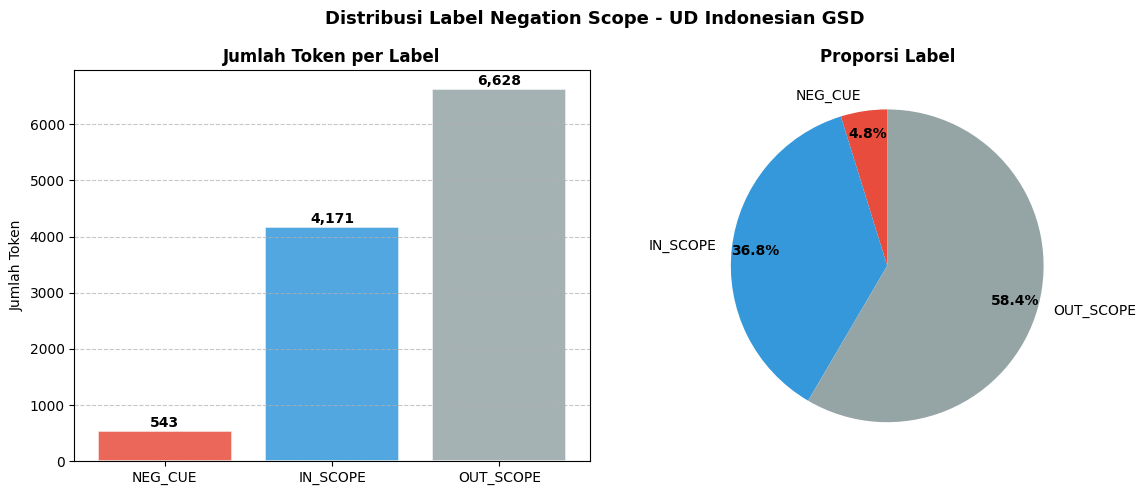

In [52]:
# ============================================
# VISUALISASI DISTRIBUSI LABEL NEGASI
# ============================================
print("=== VISUALISASI DISTRIBUSI LABEL NEGASI ===\n")

in_scope  = len(df_negasi[df_negasi['label'] == 'IN_SCOPE'])
out_scope = len(df_negasi[df_negasi['label'] == 'OUT_SCOPE'])
neg_cue   = len(df_negasi[df_negasi['label'] == 'NEG_CUE'])


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Label Negation Scope - UD Indonesian GSD',
             fontsize=13, fontweight='bold')

colors = {
    'NEG_CUE'  : '#e74c3c',
    'IN_SCOPE' : '#3498db',
    'OUT_SCOPE': '#95a5a6'
}

labels = ['NEG_CUE', 'IN_SCOPE', 'OUT_SCOPE']
counts = [neg_cue, in_scope, out_scope]
color_list = [colors[l] for l in labels]

# Plot 1: Bar chart
ax1 = axes[0]
bars = ax1.bar(labels, counts, color=color_list, alpha=0.85,
               edgecolor='white', linewidth=1.2)
ax1.set_title('Jumlah Token per Label', fontweight='bold')
ax1.set_ylabel('Jumlah Token')
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 20,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts, labels=labels, colors=color_list,
    autopct='%1.1f%%', startangle=90, pctdistance=0.85
)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
ax2.set_title('Proporsi Label', fontweight='bold')

plt.tight_layout()
plt.show()

### Save Processed Data

In [56]:
# ============================================
# PATH OUTPUT
# ============================================
BASE_PROCESSED_NEGASI = r"D:\UNIVERSITASSEBELASMARET\Semester8\File TA\Progress\Progress TA\SourceCode\TugasAkhir_MuhamadFaqihZacky\data\processed\Negasi"

# Buat folder kalau belum ada
os.makedirs(BASE_PROCESSED_NEGASI, exist_ok=True)

# ============================================
# PROSES PER SPLIT & SIMPAN
# ============================================
splits = {
    'train' : data_gsd_train,
    'dev'   : data_gsd_dev,
    'test'  : data_gsd_test,
}

df_splits = {}

for split_name, data_split in splits.items():

    # Kumpulkan sent_id yang mengandung negasi per split
    sent_ids_negasi = set()
    for kalimat in data_split:
        sent_id = kalimat.metadata.get('sent_id', '')
        for token in kalimat:
            if not isinstance(token['id'], int):
                continue
            if (token['feats'] and
                'Polarity' in token['feats'] and
                token['feats']['Polarity'] == 'Neg'):
                sent_ids_negasi.add(sent_id)
                break

    # Proses kalimat yang mengandung negasi
    negasi_data = []
    for kalimat in data_split:
        sent_id = kalimat.metadata.get('sent_id', '')
        if sent_id in sent_ids_negasi:
            hasil = label_negation_scope(kalimat)
            negasi_data.extend(hasil)

    # Buat DataFrame
    df_split = pd.DataFrame(negasi_data)
    df_splits[split_name] = df_split

    # Simpan ke CSV
    path = os.path.join(BASE_PROCESSED_NEGASI,
                        f"negasi_scope_{split_name}.csv")
    df_split.to_csv(path, index=False, encoding='utf-8')
    print(f"✓ Disimpan: negasi_scope_{split_name}.csv ({len(df_split)} token)")

# ============================================
# RINGKASAN
# ============================================
print("\n\n=== RINGKASAN DISTRIBUSI LABEL PER SPLIT ===\n")
print(f"{'LABEL':<12} {'TRAIN':<10} {'DEV':<10} {'TEST':<10} {'TOTAL':<10}")
print("-" * 45)

for label in ['NEG_CUE', 'IN_SCOPE', 'OUT_SCOPE']:
    c_train = len(df_splits['train'][df_splits['train']['label'] == label])
    c_dev   = len(df_splits['dev'][df_splits['dev']['label'] == label])
    c_test  = len(df_splits['test'][df_splits['test']['label'] == label])
    c_total = c_train + c_dev + c_test
    print(f"  {label:<12} {c_train:<10} {c_dev:<10} {c_test:<10} {c_total:<10}")

print("-" * 45)
total_train = len(df_splits['train'])
total_dev   = len(df_splits['dev'])
total_test  = len(df_splits['test'])
total_all   = total_train + total_dev + total_test
print(f"  {'TOTAL':<12} {total_train:<10} {total_dev:<10} {total_test:<10} {total_all:<10}")

# ============================================
# SAMPLE DATA
# ============================================
print("\n\n=== SAMPLE DATA TRAIN (5 per label) ===")
cols = ['sent_id', 'token', 'lemma', 'upos',
        'head', 'deprel', 'label', 'kalimat']

for label in ['NEG_CUE', 'IN_SCOPE', 'OUT_SCOPE']:
    print(f"\n--- {label} ---")
    display(df_splits['train'][
        df_splits['train']['label'] == label
    ][cols].head(5))


✓ Disimpan: negasi_scope_train.csv (9232 token)
✓ Disimpan: negasi_scope_dev.csv (1066 token)
✓ Disimpan: negasi_scope_test.csv (1044 token)


=== RINGKASAN DISTRIBUSI LABEL PER SPLIT ===

LABEL        TRAIN      DEV        TEST       TOTAL     
---------------------------------------------
  NEG_CUE      445        52         46         543       
  IN_SCOPE     3392       436        343        4171      
  OUT_SCOPE    5395       578        655        6628      
---------------------------------------------
  TOTAL        9232       1066       1044       11342     


=== SAMPLE DATA TRAIN (5 per label) ===

--- NEG_CUE ---


,sent_id,token,lemma,upos,head,deprel,label,kalimat
0,train-s16,Tidak,tidak,PART,2,advmod,NEG_CUE,Tidak ada keterangan kejatuhan Yerusalem (berb...
23,train-s17,tidak,tidak,PART,12,advmod,NEG_CUE,"Bang Yong Guk berkomentar, ""Tujuan saya dari a..."
31,train-s24,tidak,tidak,PART,5,advmod,NEG_CUE,Bagaimana bisa kita tidak mengungkapkan kesedi...
52,train-s53,tidak,tidak,PART,16,advmod,NEG_CUE,"Khidir menjawab salamnya dan bertanya, ``Dari ..."
59,train-s71,tidak,tidak,PART,6,advmod,NEG_CUE,"Membangun sebuah komunitas memang tidak mudah,..."



--- IN_SCOPE ---


,sent_id,token,lemma,upos,head,deprel,label,kalimat
1,train-s16,ada,ada,VERB,0,root,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...
2,train-s16,keterangan,keterangan,NOUN,2,obj,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...
3,train-s16,kejatuhan,kejatuhan,NOUN,3,compound,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...
4,train-s16,Yerusalem,yerusalem,PROPN,4,flat,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...
5,train-s16,berbeda,berbeda,VERB,3,appos,IN_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...



--- OUT_SCOPE ---


,sent_id,token,lemma,upos,head,deprel,label,kalimat
10,train-s16,maupun,maupun,CCONJ,17,cc,OUT_SCOPE,Tidak ada keterangan kejatuhan Yerusalem (berb...
15,train-s17,Bang,bang,PROPN,4,nsubj,OUT_SCOPE,"Bang Yong Guk berkomentar, ""Tujuan saya dari a..."
16,train-s17,Yong,yong,PROPN,1,flat,OUT_SCOPE,"Bang Yong Guk berkomentar, ""Tujuan saya dari a..."
17,train-s17,Guk,guk,PROPN,2,flat,OUT_SCOPE,"Bang Yong Guk berkomentar, ""Tujuan saya dari a..."
18,train-s17,berkomentar,berkomentar,VERB,0,root,OUT_SCOPE,"Bang Yong Guk berkomentar, ""Tujuan saya dari a..."


### Visualization Negation On Processed Data

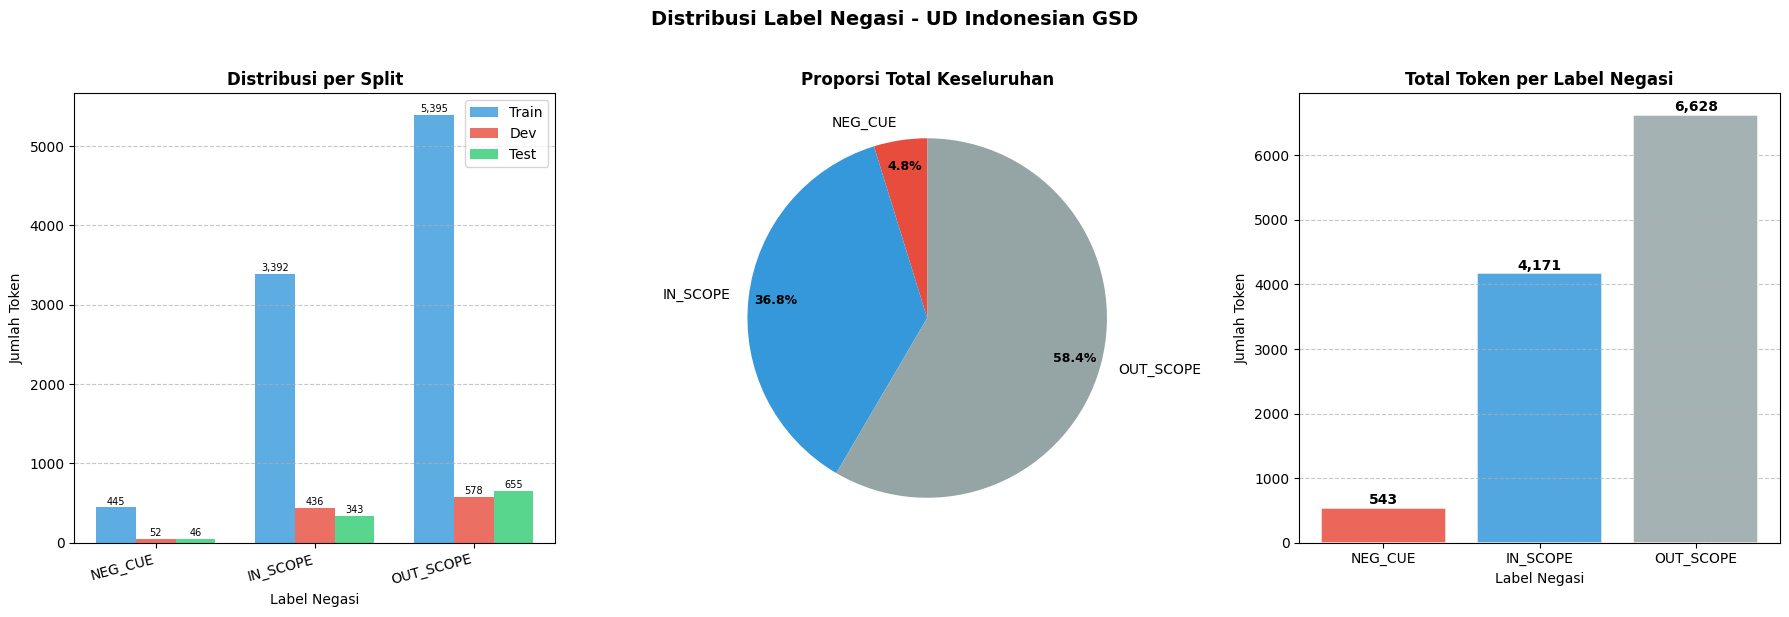

In [58]:
label_list = ['NEG_CUE', 'IN_SCOPE', 'OUT_SCOPE']
counts = {}

for label in label_list:
    c_train = len(df_splits['train'][df_splits['train']['label'] == label])
    c_dev   = len(df_splits['dev'][df_splits['dev']['label'] == label])
    c_test  = len(df_splits['test'][df_splits['test']['label'] == label])

    counts[label] = {
        'train': c_train,
        'dev'  : c_dev,
        'test' : c_test,
        'total': c_train + c_dev + c_test
    }

colors = {
    'NEG_CUE'  : '#e74c3c',
    'IN_SCOPE' : '#3498db',
    'OUT_SCOPE': '#95a5a6'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribusi Label Negasi - UD Indonesian GSD',
             fontsize=14, fontweight='bold', y=1.02)


# ============================================
# PLOT 1: Grouped Bar Chart per Split
# ============================================
ax1   = axes[0]
x     = np.arange(len(label_list))
width = 0.25

bars_train = ax1.bar(x - width, [counts[l]['train'] for l in label_list],
                     width, label='Train', color='#3498db', alpha=0.8)
bars_dev   = ax1.bar(x,         [counts[l]['dev']   for l in label_list],
                     width, label='Dev',   color='#e74c3c', alpha=0.8)
bars_test  = ax1.bar(x + width, [counts[l]['test']  for l in label_list],
                     width, label='Test',  color='#2ecc71', alpha=0.8)

ax1.set_title('Distribusi per Split', fontsize=12, fontweight='bold')
ax1.set_xlabel('Label Negasi')
ax1.set_ylabel('Jumlah Token')
ax1.set_xticks(x)
ax1.set_xticklabels(label_list, rotation=15, ha='right')
ax1.legend()
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

for bars in [bars_train, bars_dev, bars_test]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, height + 10,
                     f'{int(height):,}', ha='center', va='bottom', fontsize=7)

# ============================================
# PLOT 2: Pie Chart Total
# ============================================
ax2        = axes[1]
totals     = [counts[l]['total'] for l in label_list]
color_list = [colors[l] for l in label_list]

wedges, texts, autotexts = ax2.pie(
    totals,
    labels=label_list,
    colors=color_list,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
)
for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')

ax2.set_title('Proporsi Total Keseluruhan', fontsize=12, fontweight='bold')

# ============================================
# PLOT 3: Bar Chart Total per Label
# ============================================
ax3        = axes[2]
bar_colors = [colors[l] for l in label_list]
bars       = ax3.bar(
    label_list,
    totals,
    color=bar_colors,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

ax3.set_title('Total Token per Label Negasi', fontsize=12, fontweight='bold')
ax3.set_xlabel('Label Negasi')
ax3.set_ylabel('Jumlah Token')
ax3.yaxis.grid(True, linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, height + 10,
             f'{int(height):,}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------